# Notebook 6 — Report Evaluation (BLEU · ROUGE · CIDEr)
## Quantitative evaluation of generated radiology reports

**Loads:** trained decoder from NB5 + BioViT + BioBERT  
**Evaluates:** BLEU-1/4, ROUGE-1/2/L, CIDEr on test set  
**Saves:** `report_gen/evaluation_results.json` → used by NB7 App


## Cell 1 — Imports & Config

In [1]:
import os
os.environ['TORCH_FORCE_WEIGHTS_ONLY_LOAD'] = '0'

In [2]:
import torch, gc, os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TORCH_FORCE_WEIGHTS_ONLY_LOAD'] = '0'

gc.collect()
torch.cuda.empty_cache()

free, total = torch.cuda.mem_get_info()
print(f"Free  VRAM : {free/1024**3:.2f} GB")
print(f"Total VRAM : {total/1024**3:.2f} GB")

Free  VRAM : 1.74 GB
Total VRAM : 6.00 GB


In [3]:
import warnings; warnings.filterwarnings('ignore')
import os, json, re
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# Evaluation libraries
try:
    from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
    from rouge_score import rouge_scorer as rouge_lib
    import nltk; nltk.download('punkt', quiet=True)
    print(' BLEU + ROUGE ready')
except ImportError:
    os.system('pip install -q rouge-score nltk')
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    from rouge_score import rouge_scorer as rouge_lib
    print(' Installed and loaded')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
SEED        = 42
NUM_CLASSES = 14
MAX_SEQ_LEN = 150
EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 2

SAVE_DIR    = Path('report_gen')
EVAL_DIR    = Path('report_gen/evaluation')
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f' Device   : {DEVICE}')
print(f' Save Dir : {EVAL_DIR.resolve()}')

 BLEU + ROUGE ready
 Device   : cuda
 Save Dir : D:\Projects\ScratchRadiology\report_gen\evaluation


## Cell 2 — Rebuild Architecture + Load Vocab (same as NB5)

In [4]:
with open(SAVE_DIR / 'vocab.json') as f:
    vocab_data = json.load(f)

# ← FIX: handle flat dict saved by NB5
if 'word2idx' in vocab_data:
    word2idx = vocab_data['word2idx']
    idx2word = {int(k): v for k, v in vocab_data['idx2word'].items()}
else:
    word2idx = vocab_data
    idx2word = {v: k for k, v in vocab_data.items()}

VOCAB_SIZE = len(word2idx)
PAD_IDX    = word2idx['<PAD>']
SOS_IDX    = word2idx['<SOS>']
EOS_IDX    = word2idx['<EOS>']
UNK_IDX    = word2idx['<UNK>']
print(f' Vocab loaded : {VOCAB_SIZE:,} words')

 Vocab loaded : 1,879 words


## Cell 3 — Load Test Data & Generate Reports

In [10]:
import warnings; warnings.filterwarnings('ignore')
import os, json, re
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
SEED        = 42
NUM_CLASSES = 14
MAX_SEQ_LEN = 150
EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 2
SAVE_DIR    = Path('report_gen')
EVAL_DIR    = Path('report_gen/evaluation')
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# -- Load Vocab ----------------------------------------------------------------
with open(SAVE_DIR / 'vocab.json', encoding='utf-8') as f:
    vocab_data = json.load(f)

if 'word2idx' in vocab_data:
    word2idx = vocab_data['word2idx']
    idx2word = {int(k): v for k, v in vocab_data['idx2word'].items()}
else:
    word2idx = vocab_data
    idx2word = {v: k for k, v in vocab_data.items()}

VOCAB_SIZE = len(word2idx)
PAD_IDX    = word2idx['<PAD>']
SOS_IDX    = word2idx['<SOS>']
EOS_IDX    = word2idx['<EOS>']
UNK_IDX    = word2idx['<UNK>']
print(f'Vocab loaded : {VOCAB_SIZE:,} words')

# -- Model Definitions --------------------------------------------------------
class BioViT(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.vit      = timm.create_model('vit_base_patch16_224', pretrained=False)
        in_feats      = self.vit.head.in_features
        self.vit.head = nn.Identity()
        self.head     = nn.Sequential(nn.LayerNorm(in_feats),
                                      nn.Linear(in_feats, num_classes))
    def forward(self, x): return self.head(self.vit(x))


class ImageEncoder(nn.Module):
    def __init__(self, ckpt_path, device):
        super().__init__()
        biovit = BioViT(num_classes=NUM_CLASSES)
        ckpt   = torch.load(ckpt_path, map_location=device, weights_only=False)
        biovit.load_state_dict(ckpt['model_state_dict'])
        self.vit      = biovit.vit
        self.feat_dim = 768
        for p in self.vit.parameters(): p.requires_grad = False
    def forward(self, x): return self.vit(x)


class TextEncoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        model_name     = 'dmis-lab/biobert-base-cased-v1.2'
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        try:
            self.bert = AutoModel.from_pretrained(model_name, trust_remote_code=True,
                                                  use_safetensors=True)
        except:
            self.bert = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.feat_dim = 768
        self.device   = device
        for p in self.bert.parameters(): p.requires_grad = False
    def forward(self, texts):
        enc = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=64, return_tensors='pt').to(self.device)
        with torch.no_grad():
            out = self.bert(**enc)
        return out.last_hidden_state[:, 0, :]


class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, encoder_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc_init_h = nn.Linear(encoder_dim, hidden_dim)
        self.fc_init_c = nn.Linear(encoder_dim, hidden_dim)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                 batch_first=True, dropout=0.3)
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(0.3)
    def forward(self, encoder_out, input_ids):
        embeds = self.dropout(self.embedding(input_ids))
        h0     = self.fc_init_h(encoder_out).unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        c0     = self.fc_init_c(encoder_out).unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        out, _ = self.lstm(embeds, (h0, c0))
        return self.fc_out(out)


# -- Load Models ---------------------------------------------------------------
print('Loading models...')
img_encoder  = ImageEncoder(Path('ScratchCnnModels') / 'BioViT.pth', DEVICE).to(DEVICE)
text_encoder = TextEncoder(DEVICE).to(DEVICE)
encoder_dim  = img_encoder.feat_dim + text_encoder.feat_dim   # 1536

decoder = LSTMDecoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM,
                      NUM_LAYERS, encoder_dim, PAD_IDX).to(DEVICE)

ckpt = torch.load(SAVE_DIR / 'best_decoder.pth', map_location=DEVICE, weights_only=False)
decoder.load_state_dict(ckpt['decoder_state'])
# BioBERT uses pretrained weights directly — no state dict to load
decoder.eval()
img_encoder.eval()
text_encoder.eval()
print('All models loaded')

# -- Helpers -------------------------------------------------------------------
def tokenize(text):
    return str(text).lower().split()

def get_img_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def generate_report(img_path, clinical_history='', max_len=MAX_SEQ_LEN):
    transform  = get_img_transform()
    img        = cv2.imread(str(img_path))
    if img is None: return ''
    img        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = transform(image=img)['image'].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        img_feats   = img_encoder(img_tensor)
        text_feats  = text_encoder([str(clinical_history)])
        encoder_out = torch.cat([img_feats, text_feats], dim=-1)
        h = decoder.fc_init_h(encoder_out).unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        c = decoder.fc_init_c(encoder_out).unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        input_ids = torch.tensor([[SOS_IDX]], dtype=torch.long).to(DEVICE)
        generated = []
        for _ in range(max_len):
            emb        = decoder.embedding(input_ids)
            out, (h,c) = decoder.lstm(emb, (h, c))
            logits     = decoder.fc_out(out[:, -1, :])
            next_tok   = logits.argmax(dim=-1).item()
            if next_tok == EOS_IDX: break
            generated.append(next_tok)
            input_ids  = torch.tensor([[next_tok]], dtype=torch.long).to(DEVICE)
    words = [idx2word.get(i, '') for i in generated
             if i not in [PAD_IDX, SOS_IDX, EOS_IDX]]
    return ' '.join(words)

# -- Load Test Data ------------------------------------------------------------
df = pd.read_csv('preprocessed_df.csv')
df['findings_clean']   = df['findings_clean'].fillna('')
df['impression_clean'] = df['impression_clean'].fillna('')
df['clinical_history'] = df.get('clinical_history',
                                 pd.Series(['']*len(df))).fillna('')

def build_full_report(row):
    f = str(row.get('findings_clean',   '')).strip()
    i = str(row.get('impression_clean', '')).strip()
    parts = []
    if f and f != 'nan': parts.append('FINDINGS: '   + f)
    if i and i != 'nan': parts.append('IMPRESSION: ' + i)
    return ' '.join(parts).strip()

df['full_report'] = df.apply(build_full_report, axis=1)
df = df[df['full_report'].str.len() > 10].reset_index(drop=True)

idx_all            = np.arange(len(df))
idx_train, idx_tmp = train_test_split(idx_all, test_size=0.2, random_state=SEED)
idx_val,  idx_test = train_test_split(idx_tmp, test_size=0.5, random_state=SEED)
test_df            = df.iloc[idx_test].reset_index(drop=True)
print(f'Test samples : {len(test_df)}')

# -- Generate Reports ----------------------------------------------------------
print('\nGenerating reports for test set...')
references, hypotheses, sample_results = [], [], []

for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Generating'):
    real_report = str(row['full_report'])
    gen_report  = generate_report(row['frontal_path'],
                                   str(row.get('clinical_history', '')))
    references.append([tokenize(real_report)])
    hypotheses.append(tokenize(gen_report))
    sample_results.append({
        'uid'      : str(row.get('uid', i)),
        'real'     : real_report,
        'generated': gen_report,
        'history'  : str(row.get('clinical_history', '')),
    })

print(f'Generated {len(sample_results)} reports')

Vocab loaded : 1,879 words
Loading models...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1359.40it/s]
[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded
Test samples : 334

Generating reports for test set...


Generating: 100%|██████████| 334/334 [01:54<00:00,  2.91it/s]

Generated 334 reports


## Cell 4 — BLEU + ROUGE + CIDEr Scores

  EVALUATION RESULTS — Test Set
  BLEU-1    : 0.3293  XXXXXXXXXXXXX
  BLEU-2    : 0.1981  XXXXXXX
  BLEU-3    : 0.1264  XXXXX
  BLEU-4    : 0.0829  XXX
  ROUGE-1   : 0.4079  XXXXXXXXXXXXXXXX
  ROUGE-2   : 0.1627  XXXXXX
  ROUGE-L   : 0.3201  XXXXXXXXXXXX
  Test Samples : 334

Saved -> report_gen\evaluation/evaluation_results.json
Saved -> report_gen\evaluation/sample_results.json


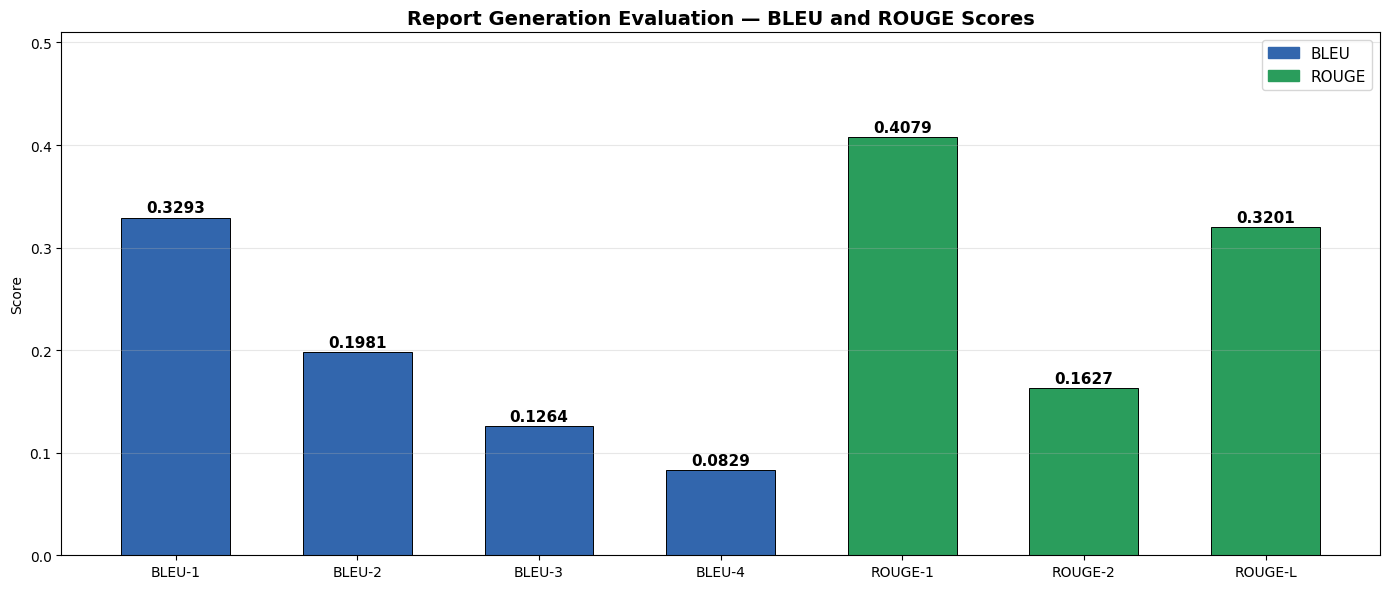

Graph -> report_gen\evaluation/evaluation_scores.png


In [11]:
smooth = SmoothingFunction().method1
bleu1  = corpus_bleu(references, hypotheses, weights=(1,0,0,0),          smoothing_function=smooth)
bleu2  = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0),      smoothing_function=smooth)
bleu3  = corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0),    smoothing_function=smooth)
bleu4  = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25),smoothing_function=smooth)

scorer   = rouge_lib.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
r1_list, r2_list, rl_list = [], [], []
for ref_list, hyp in zip(references, hypotheses):
    ref_text = ' '.join(ref_list[0])
    hyp_text = ' '.join(hyp)
    scores   = scorer.score(ref_text, hyp_text)
    r1_list.append(scores['rouge1'].fmeasure)
    r2_list.append(scores['rouge2'].fmeasure)
    rl_list.append(scores['rougeL'].fmeasure)

rouge1 = float(np.mean(r1_list))
rouge2 = float(np.mean(r2_list))
rougeL = float(np.mean(rl_list))

eval_results = {
    'BLEU-1' : round(bleu1,  4),
    'BLEU-2' : round(bleu2,  4),
    'BLEU-3' : round(bleu3,  4),
    'BLEU-4' : round(bleu4,  4),
    'ROUGE-1': round(rouge1, 4),
    'ROUGE-2': round(rouge2, 4),
    'ROUGE-L': round(rougeL, 4),
    'test_samples': len(test_df),
}

with open(EVAL_DIR / 'evaluation_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
with open(EVAL_DIR / 'sample_results.json', 'w') as f:
    json.dump(sample_results[:20], f, indent=2)

print('='*55)
print('  EVALUATION RESULTS — Test Set')
print('='*55)
for k, v in eval_results.items():
    if k != 'test_samples':
        bar = 'X' * int(v * 40)
        print(f'  {k:<10}: {v:.4f}  {bar}')
print('='*55)
print(f'  Test Samples : {len(test_df)}')
print(f'\nSaved -> {EVAL_DIR}/evaluation_results.json')
print(f'Saved -> {EVAL_DIR}/sample_results.json')

import matplotlib.pyplot as plt
metrics = ['BLEU-1','BLEU-2','BLEU-3','BLEU-4','ROUGE-1','ROUGE-2','ROUGE-L']
values  = [eval_results[m] for m in metrics]
colors  = ['#3266ad']*4 + ['#2a9d5c']*3

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=0.7, width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Report Generation Evaluation — BLEU and ROUGE Scores',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, max(values)*1.25)
ax.grid(axis='y', alpha=0.3)
patches = [plt.Rectangle((0,0),1,1, color='#3266ad', label='BLEU'),
           plt.Rectangle((0,0),1,1, color='#2a9d5c', label='ROUGE')]
ax.legend(handles=patches, fontsize=11)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'evaluation_scores.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Graph -> {EVAL_DIR}/evaluation_scores.png')

## Cell 5 — Sample Report Comparison

In [12]:
print('SAMPLE GENERATED REPORTS')
print('='*70)
for i, s in enumerate(sample_results[:5]):
    print(f'\n  Sample {i+1} | UID: {s["uid"]}')
    print(f'  History  : {s["history"][:80]}')
    print(f'  REAL     : {s["real"][:200]}')
    print(f'  GENERATED: {s["generated"][:200]}')
    indiv_bleu = sentence_bleu(
        [tokenize(s["real"])], tokenize(s["generated"]),
        smoothing_function=smooth)
    scores = scorer.score(s["real"], s["generated"])
    print(f'  BLEU-1   : {indiv_bleu:.4f}  ROUGE-1: {scores["rouge1"].fmeasure:.4f}')
    print('  ' + '-'*65)

print('\nNB6 Complete. Run app.py for the App.')

SAMPLE GENERATED REPORTS

  Sample 1 | UID: 2532
  History  : year old female, chest pain
  REAL     : FINDINGS: stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. interstitial opacities greatest in the central lungs and bases. IMPRESSION: 1. cardiomegaly, questi
  GENERATED: findings: low lung volumes without focal consolidation, effusion, or pneumothorax. normal heart size. mild unfolding of the thoracic aorta. no focal airspace consolidation. no pleural effusion or pneu
  BLEU-1   : 0.0118  ROUGE-1: 0.2143
  -----------------------------------------------------------------

  Sample 2 | UID: 3156
  History  : year old woman with positive ppd.
  REAL     : FINDINGS: the lungs are clear bilaterally. specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous struct
  GENERATED: findings: heart size within normal limits, stable cardiomediastinal silhouette.